In [1]:
%reset -f


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import scipy
from scipy.spatial import distance
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import os
from decimal import Decimal
import datetime as dt

#Input
dataFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/data.csv'
#Output
meanFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/mean.csv'
countFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/count.csv'

raw_df = pd.read_csv(dataFILE)

def dtime_fn(y, d):
  dtime = dt.datetime(int(y), 1, 1) + dt.timedelta(days=int(d) - 1)
  return dtime

raw_df['dtime'] = raw_df.apply(lambda row: dtime_fn(row['year'], row['doy']), axis=1)
raw_df['month'] = pd.DatetimeIndex(raw_df['dtime']).month

mask_df = raw_df.mask(raw_df[['Station', 'GridMET', 'DayMET', 'PRISM']] == 0, np.nan)
print(mask_df)

group_sum = raw_df.groupby(['year', 'month'])[['Station', 'GridMET', 'DayMET', 'PRISM']].sum()
print(group_sum)

mask_df['year'] = raw_df['year']
mask_df['month'] = raw_df['month']
group_ct = mask_df.groupby(['year', 'month'])[['Station', 'GridMET', 'DayMET', 'PRISM']].count()
print(group_ct)

group_avg = group_sum / group_ct
print(group_avg)
group_avg.fillna(0.0).round(4).to_csv(meanFILE)
group_ct.to_csv(countFILE)


       year  doy  Station  GridMET  DayMET  PRISM dtime  month
0       NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
1       NaN  NaN    2.032      1.0     1.0    NaN   NaT    NaN
2       NaN  NaN      NaN      NaN     NaN   0.49   NaT    NaN
3       NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
4       NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
...     ...  ...      ...      ...     ...    ...   ...    ...
15325   NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
15326   NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
15327   NaN  NaN    0.254      NaN     NaN    NaN   NaT    NaN
15328   NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
15329   NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN

[15330 rows x 8 columns]
            Station  GridMET  DayMET    PRISM
year month                                   
1982 1       35.306       36   43.57   32.830
     2       31.750       36   30.93   26.215
     3       65.024       70   67.

In [ ]:
import pandas as pd
import numpy as np

# Sample DataFrame
data = {'A': [1, 2, 3, 4, 5],
        'B': [6, 7, 8, 9, 10],
        'C': [11, 12, 13, 14, 15]}
df = pd.DataFrame(data)

# Columns to apply mask
columns_to_mask = ['A', 'B']

# Condition for the mask (e.g., values greater than 3)
mask_condition = df[columns_to_mask] > 3

# Apply the mask to selected columns
df[columns_to_mask] = df[columns_to_mask].mask(mask_condition, np.nan)

print(df)


mask_df = raw_df.mask(raw_df[['ground', 'GridMET', 'DayMET', 'PRISM']] == 0, np.nan)
mask_df['year'] = raw_df['year']
mask_df['doy'] = raw_df['doy']
mask_df['month'] = raw_df['month']
mask_df['dtime'] = raw_df['dtime']


     A   B   C
0  1.0 NaN  11
1  2.0 NaN  12
2  3.0 NaN  13
3  NaN NaN  14
4  NaN NaN  15


KeyError: "['ground'] not in index"

     year  month  Station  GridMET   DayMET    PRISM
0    1982      1   7.0612   4.5000   6.2243   4.1038
1    1982      2   6.3500   7.2000   6.1860   4.3692
2    1982      3   8.1280   5.3846   9.6143   6.6150
3    1982      4   9.3980   5.0625   7.4145   6.4721
4    1982      5  19.8120  10.0000  19.3783  15.2250
..    ...    ...      ...      ...      ...      ...
499  2023      8  15.6754   6.0000   5.8300   6.3700
500  2023      9   3.1327  17.0000  17.3060   8.2320
501  2023     10  16.4253  17.0000  17.1200  12.5930
502  2023     11   9.1440   6.5000   7.6880   6.8600
503  2023     12   4.9389  17.0000  21.9800  16.2108

[504 rows x 6 columns]


<ipython-input-41-4cfe9069115d>:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[0]
<ipython-input-41-4cfe9069115d>:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[0]
<ipython-input-41-4cfe9069115d>:71: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[0]


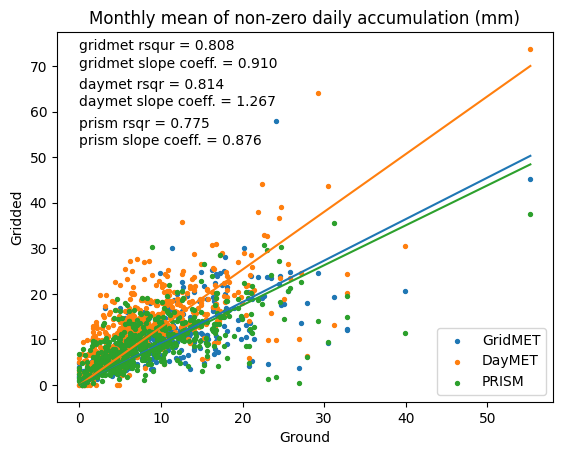

In [41]:
import pandas as pd
import numpy as np
import scipy
import statsmodels.api as sm
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import os
from decimal import Decimal
import datetime as dt

meanFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/mean.csv'
countFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/count.csv'

mean_df = pd.read_csv(meanFILE)
count_df = pd.read_csv(countFILE)
print(mean_df)

ground = mean_df['Station']
gridmet = mean_df['GridMET']
daymet = mean_df['DayMET']
prism = mean_df['PRISM']

plt.scatter(ground, gridmet, label='GridMET', s=8)

plt.scatter(ground, daymet, label='DayMET', s=8)

plt.scatter(ground, prism, label='PRISM', s=8)

plt.legend()


y = gridmet
x = ground
#X = sm.add_constant(x)
model = sm.OLS(y, x)
results = model.fit()
slope = results.params[0]
slope = round(slope, 3)
#intc = results.params[0]
#slope_coeff_p = round(results.pvalues[1], 2)
rsq = round(results.rsquared, 3)
#plt.text(0, max(y), 'slope coeff. p value = ' + str(slope_coeff_p))
plt.text(0, 1.27*max(y), 'gridmet rsqur = ' + str(rsq))
plt.text(0, 1.20*max(y), 'gridmet slope coeff. = {}'.format('0.910'))
plt.plot([0, max(x)], [0, slope*max(x)])



y = daymet
x = ground
#X = sm.add_constant(x)
model = sm.OLS(y, x)
results = model.fit()
slope = results.params[0]
slope = round(slope, 3)
#intc = results.params[0]
#slope_coeff_p = round(results.pvalues[1], 2)
rsq = round(results.rsquared, 3)
#plt.text(0, max(y), 'slope coeff. p value = ' + str(slope_coeff_p))
plt.text(0, 0.88*max(y), 'daymet rsqr = ' + str(rsq))
plt.text(0, 0.83*max(y), 'daymet slope coeff. = {}'.format(slope, 3))
plt.plot([0, max(x)], [0, slope*max(x)])



y = prism
x = ground
#X = sm.add_constant(x)
model = sm.OLS(y, x)
results = model.fit()
slope = results.params[0]
slope = round(slope, 3)
#intc = results.params[0]
#slope_coeff_p = round(results.pvalues[1], 2)
rsq = round(results.rsquared, 3)
#plt.text(0, max(y), 'slope coeff. p value = ' + str(slope_coeff_p))
plt.text(0, 1.51*max(y), 'prism rsqr = ' + str(rsq))
plt.text(0, 1.41*max(y), 'prism slope coeff. = {}'.format(slope, 3))
plt.plot([0, max(x)], [0, slope*max(x)])

plt.title('Monthly mean of non-zero daily accumulation (mm)')
plt.ylabel('Gridded')
plt.xlabel('Ground')

plt.savefig('/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/scatterplt.png', dpi=600)






     year  month  Station  GridMET   DayMET    PRISM
0    1982      1   7.0612   4.5000   6.2243   4.1038
1    1982      2   6.3500   7.2000   6.1860   4.3692
2    1982      3   8.1280   5.3846   9.6143   6.6150
3    1982      4   9.3980   5.0625   7.4145   6.4721
4    1982      5  19.8120  10.0000  19.3783  15.2250
..    ...    ...      ...      ...      ...      ...
499  2023      8  15.6754   6.0000   5.8300   6.3700
500  2023      9   3.1327  17.0000  17.3060   8.2320
501  2023     10  16.4253  17.0000  17.1200  12.5930
502  2023     11   9.1440   6.5000   7.6880   6.8600
503  2023     12   4.9389  17.0000  21.9800  16.2108

[504 rows x 6 columns]


<ipython-input-12-cd8032417f0b>:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[0]
<ipython-input-12-cd8032417f0b>:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[0]
<ipython-input-12-cd8032417f0b>:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[0]


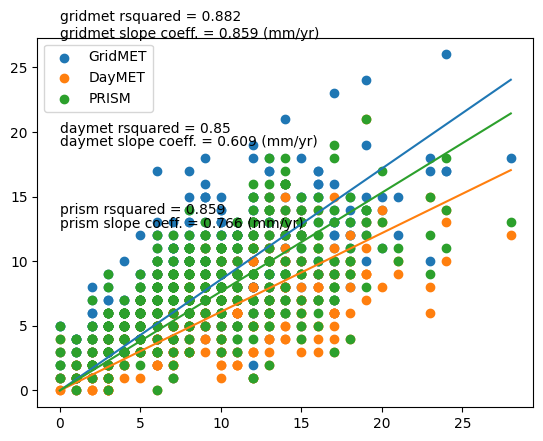

In [12]:
import pandas as pd
import numpy as np
import scipy
import statsmodels.api as sm
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import os
from decimal import Decimal
import datetime as dt

meanFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/mean.csv'
countFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/count.csv'

mean_df = pd.read_csv(meanFILE)
count_df = pd.read_csv(countFILE)
print(mean_df)

ground = count_df['Station']
gridmet = count_df['GridMET']
daymet = count_df['DayMET']
prism = count_df['PRISM']

plt.scatter(ground, gridmet, label='GridMET')

plt.scatter(ground, daymet, label='DayMET')

plt.scatter(ground, prism, label='PRISM')

plt.legend()


y = gridmet
x = ground
#X = sm.add_constant(x)
model = sm.OLS(y, x)
results = model.fit()
slope = results.params[0]
#intc = results.params[0]
#slope_coeff_p = round(results.pvalues[1], 2)
rsq = round(results.rsquared, 3)
#plt.text(0, max(y), 'slope coeff. p value = ' + str(slope_coeff_p))
plt.text(0, 1.10*max(y), 'gridmet rsquared = ' + str(rsq))
plt.text(0, 1.05*max(y), 'gridmet slope coeff. = {} (mm/yr)'.format(str(round(slope, 3))))
plt.plot([0, max(x)], [0, slope*max(x)])


y = daymet
x = ground
#X = sm.add_constant(x)
model = sm.OLS(y, x)
results = model.fit()
slope = results.params[0]
#intc = results.params[0]
#slope_coeff_p = round(results.pvalues[1], 2)
rsq = round(results.rsquared, 3)
#plt.text(0, max(y), 'slope coeff. p value = ' + str(slope_coeff_p))
plt.text(0, 0.95*max(y), 'daymet rsquared = ' + str(rsq))
plt.text(0, 0.90*max(y), 'daymet slope coeff. = {} (mm/yr)'.format(str(round(slope, 3))))
plt.plot([0, max(x)], [0, slope*max(x)])


y = prism
x = ground
#X = sm.add_constant(x)
model = sm.OLS(y, x)
results = model.fit()
slope = results.params[0]
#intc = results.params[0]
#slope_coeff_p = round(results.pvalues[1], 2)
rsq = round(results.rsquared, 3)
#plt.text(0, max(y), 'slope coeff. p value = ' + str(slope_coeff_p))
plt.text(0, 0.65*max(y), 'prism rsquared = ' + str(rsq))
plt.text(0, 0.60*max(y), 'prism slope coeff. = {} (mm/yr)'.format(str(round(slope, 3))))
plt.plot([0, max(x)], [0, slope*max(x)])












In [ ]:
import pandas as pd
import numpy as np
import scipy
from scipy.spatial import distance
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import os
from decimal import Decimal
import datetime as dt

#Input
dataFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/data.csv'
#Output
meanFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/mean_monthly.csv'
countFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/count_monthly.csv'

raw_df = pd.read_csv(dataFILE)

def dtime_fn(y, d):
  dtime = dt.datetime(int(y), 1, 1) + dt.timedelta(days=int(d) - 1)
  return dtime

raw_df['dtime'] = raw_df.apply(lambda row: dtime_fn(row['year'], row['doy']), axis=1)
raw_df['month'] = pd.DatetimeIndex(raw_df['dtime']).month

mask_df = raw_df.mask(raw_df[['Station', 'GridMET', 'DayMET', 'PRISM']] == 0, np.nan)
print(mask_df)

group_sum = raw_df.groupby(['month'])[['Station', 'GridMET', 'DayMET', 'PRISM']].sum().divide(42)
print(group_sum)

mask_df['year'] = raw_df['year']
mask_df['month'] = raw_df['month']
group_ct = mask_df.groupby(['month'])[['Station', 'GridMET', 'DayMET', 'PRISM']].count().divide(42)
print(group_ct)

group_avg = group_sum / group_ct
print(group_avg)
group_avg.fillna(0.0).round(4).to_csv(meanFILE)
group_ct.to_csv(countFILE)


       year  doy  Station  GridMET  DayMET  PRISM dtime  month
0       NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
1       NaN  NaN    1.960      1.0     1.0    NaN   NaT    NaN
2       NaN  NaN      NaN      NaN     NaN  0.508   NaT    NaN
3       NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
4       NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
...     ...  ...      ...      ...     ...    ...   ...    ...
15325   NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
15326   NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
15327   NaN  NaN    0.254      NaN     NaN    NaN   NaT    NaN
15328   NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN
15329   NaN  NaN      NaN      NaN     NaN    NaN   NaT    NaN

[15330 rows x 8 columns]
          Station     GridMET      DayMET       PRISM
month                                                
1       61.410024   64.928571   70.763333   65.610619
2       65.809405   70.000000   75.187857   67.219286
3 

    month  Station  GridMET   DayMET    PRISM
0       1   6.0262   8.3908  10.6909   8.2504
1       2   6.7250   8.5714  11.1586   8.1127
2       3   7.6702   9.4588  12.2724   9.4545
3       4   7.6664  10.3149  14.3612  11.4360
4       5  10.8209  11.4819  16.9728  13.0608
5       6  10.2333   8.6962  15.1983  10.9527
6       7   6.7875   6.3131  12.9878   7.8325
7       8   9.5994   8.5948  15.8321  10.5754
8       9   7.6718   9.3694  16.6527  11.0965
9      10  11.5459  12.2830  17.6876  13.4512
10     11   7.5633   9.1490  12.6227   9.9245
11     12   7.7154  10.0610  12.4135   9.9548


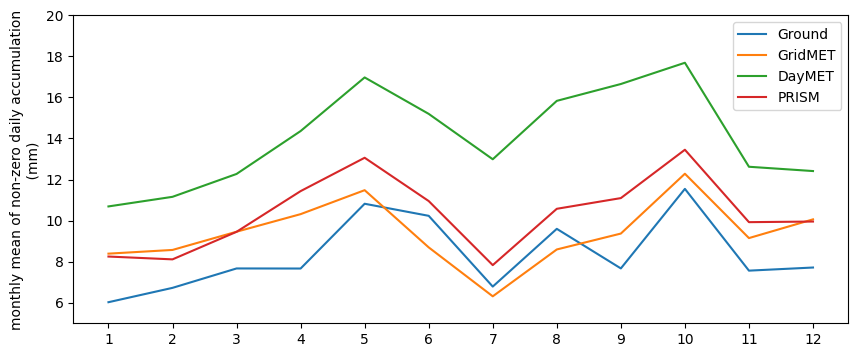

In [ ]:
import pandas as pd
import numpy as np
import scipy
from scipy.spatial import distance
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import os
from decimal import Decimal
import datetime as dt

meanFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/mean_monthly.csv'
countFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/count_monthly.csv'

mean_df = pd.read_csv(meanFILE)
count_df = pd.read_csv(countFILE)
print(mean_df)

plt.figure(figsize=(10, 4))

plt.ylabel('monthly mean of non-zero daily accumulation\n    (mm)')
plt.xticks(range(1, 13))
plt.ylim(5, 20)

plt.plot(range(1, 13), mean_df['Station'], label='Ground')
plt.plot(range(1, 13), mean_df['GridMET'], label='GridMET')
plt.plot(range(1, 13), mean_df['DayMET'], label='DayMET')
plt.plot(range(1, 13), mean_df['PRISM'], label='PRISM')


plt.legend()


    month  Station  GridMET   DayMET    PRISM
0       1   6.0262   8.3908  10.6909   8.2504
1       2   6.7250   8.5714  11.1586   8.1127
2       3   7.6702   9.4588  12.2724   9.4545
3       4   7.6664  10.3149  14.3612  11.4360
4       5  10.8209  11.4819  16.9728  13.0608
5       6  10.2333   8.6962  15.1983  10.9527
6       7   6.7875   6.3131  12.9878   7.8325
7       8   9.5994   8.5948  15.8321  10.5754
8       9   7.6718   9.3694  16.6527  11.0965
9      10  11.5459  12.2830  17.6876  13.4512
10     11   7.5633   9.1490  12.6227   9.9245
11     12   7.7154  10.0610  12.4135   9.9548


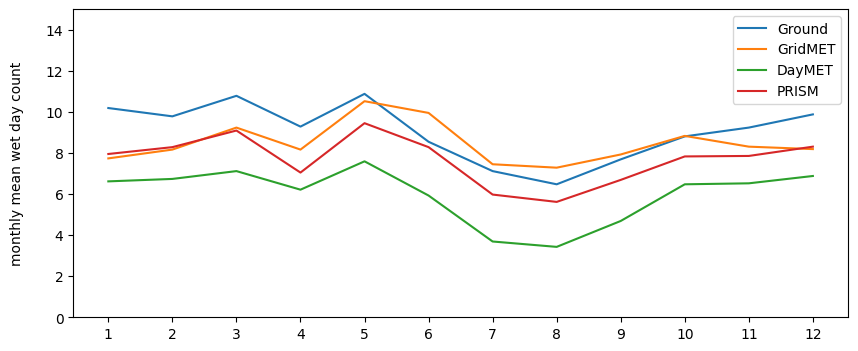

In [ ]:
import pandas as pd
import numpy as np
import scipy
from scipy.spatial import distance
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import os
from decimal import Decimal
import datetime as dt

meanFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/mean_monthly.csv'
countFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/count_monthly.csv'

mean_df = pd.read_csv(meanFILE)
count_df = pd.read_csv(countFILE)
print(mean_df)

plt.figure(figsize=(10, 4))

plt.ylabel('monthly mean wet day count\n')
plt.xticks(range(1, 13))
plt.ylim(0, 15)

plt.plot(range(1, 13), count_df['Station'], label='Ground')
plt.plot(range(1, 13), count_df['GridMET'], label='GridMET')
plt.plot(range(1, 13), count_df['DayMET'], label='DayMET')
plt.plot(range(1, 13), count_df['PRISM'], label='PRISM')


plt.legend()


       year  doy  Station  GridMET  DayMET  PRISM
0      1982    1    0.000        0     0.0   0.00
1      1982    2    2.032        1     1.0   0.00
2      1982    3    0.000        0     0.0   0.49
3      1982    4    0.000        0     0.0   0.00
4      1982    5    0.000        0     0.0   0.00
...     ...  ...      ...      ...     ...    ...
15325  2023  361    0.000        0     0.0   0.00
15326  2023  362    0.000        0     0.0   0.00
15327  2023  363    0.254        0     0.0   0.00
15328  2023  364    0.000        0     0.0   0.00
15329  2023  365    0.000        0     0.0   0.00

[15330 rows x 6 columns]


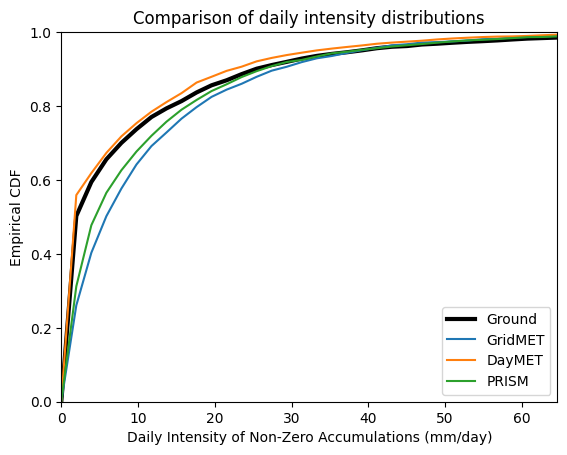

In [44]:
import pandas as pd
import numpy as np
import scipy
from scipy.spatial import distance
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import os
from decimal import Decimal
import datetime as dt

dataFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/data.csv'

data_df = pd.read_csv(dataFILE)
print(data_df)

with open(os.path.join(dataFILE)) as f:
  lines = f.readlines()

p = [float(l.split(',')[2]) for l in lines[1:] if float(l.split(',')[3]) > 0.0]
ground_p = p

p = [float(l.split(',')[3]) for l in lines[1:] if float(l.split(',')[4]) > 0.0]
gridmet_p = p

p = [float(l.split(',')[4]) for l in lines[1:] if float(l.split(',')[5]) > 0.0]
daymet_p = p

p = [float(l.split(',')[5]) for l in lines[1:] if float(l.split(',')[5]) > 0.0]
prism_p = p


max_value = max(max(ground_p), max(gridmet_p), max(daymet_p), max(prism_p))
min_value = min(min(ground_p), max(gridmet_p), min(daymet_p), min(prism_p))


bins_cdf = np.linspace(min_value, max_value, 101)

ground_h = np.array(np.histogram(ground_p, bins_cdf)[0], float)
gridmet_h = np.array(np.histogram(gridmet_p, bins_cdf)[0], float)
daymet_h = np.array(np.histogram(daymet_p, bins_cdf)[0], float)
prism_h = np.array(np.histogram(prism_p, bins_cdf)[0], float)


ground_cdf = np.array([0.0] + [sum(ground_h[:i+1])/len(ground_p) for i, value in enumerate(ground_h)])
gridmet_cdf = np.array([0.0] + [sum(gridmet_h[:i+1])/len(gridmet_p) for i, value in enumerate(gridmet_h)])
daymet_cdf = np.array([0.0] + [sum(daymet_h[:i+1])/len(daymet_p) for i, value in enumerate(daymet_h)])
prism_cdf = np.array([0.0] + [sum(prism_h[:i+1])/len(prism_p) for i, value in enumerate(prism_h)])


plt.plot(bins_cdf, ground_cdf, color='black', label='Ground', linewidth=3, zorder=-999)
plt.plot(bins_cdf, gridmet_cdf, label='GridMET')
plt.plot(bins_cdf, daymet_cdf, label='DayMET')
plt.plot(bins_cdf, prism_cdf, label='PRISM')

#ax.set_title(labels[i], fontsize=10)
#ax.legend([ground, daymet, gridmet, prism], ['ghcnd (ref.)', 'cligen {}'.format(str(cligen_dev)), 'swpar45 {}'.format(str(swpar45_dev)), 'daymet {}'.format(str(daymet_dev)), 'gridmet {}'.format(str(gridmet_dev)), 'prism {}'.format(str(prism_dev))], loc='lower right', fontsize=8, markerscale=0.5, title_fontsize=8, title='X² distance')

plt.title('Comparison of daily intensity distributions')
plt.xlim(0, 0.33*max_value)
plt.ylim(0, 1)
plt.xlabel('Daily Intensity of Non-Zero Accumulations (mm/day)')
plt.ylabel('Empirical CDF')
plt.legend()

plt.savefig('/content/drive/My Drive/Colab Notebooks/TeamProjects/Merilynn/cdf.png', dpi=600)


